# 01 数据管道 — 三市场统一接口

### 代理配置

```
v2rayN -> SOCKS5 127.0.0.1:10808 -> 自动为美股/加密启用
已写入 .env:  PROXY_SOCKS5=socks5://127.0.0.1:10808
```

| 市场 | 数据源 | 代理 | 状态 |
|------|--------|------|------|
| A股 | baostock | 直连 | OK |
| 加密 | ccxt Gate.io/Kraken | 自动切换 | OK |
| 美股+港股 | yfinance | SOCKS5 | OK |

---
| 章节 | 概念 |
|------|------|
| 1. 架构全景 | API -> DataFrame -> SQLite 三层分离 |
| 2. 统一 Schema | 10列标准，三市场遵守 |
| 3. ABC 抽象基类 | 多态：同一接口，不同实现 |
| 4. AShareSource | baostock 直连 |
| 5. CryptoSource | Gate.io直连 -> Kraken代理自动切换 |
| 6. USStockSource | yfinance + SOCKS5 代理 |
| 7. 三市场对比 | 同一套代码，三个市场 |
| 8. SQLite 存储 | WAL+UPSERT+缓存加速 |
| 9. 端到端 | 存->读->画，断网可用 |

## 1. 架构全景

```
source.get_history(symbols, start, end)   <- 你写的唯一一行
        |
第1层: DataSource (适配)
  _fetch()  -> API (直连或代理)
  _normalize() -> 统一Schema
  -> 标准DataFrame (内存)
        |
第2层: DataFrame (分析)
  筛选、画图、算指标、回测
        |
第3层: DataStore (持久化)
  store.save() -> SQLite
  store.load()  -> 毫秒级，断网可用
```

**核心设计**：三层互不耦合。API 不知道 SQLite，SQLite 不知道代理。

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("OK")

OK


## 2. 统一 Schema -- 10列标准

所有市场输出完全一致的列，这是系统的数据契约。

In [2]:
from data.schema import OHLCV_COLUMNS
for i, c in enumerate(OHLCV_COLUMNS):
    print(f"  {i+1}. {c}")
print()
print("这10列是所有数据源的共同契约")

  1. symbol
  2. date
  3. open
  4. high
  5. low
  6. close
  7. volume
  8. amount
  9. market
  10. interval

这10列是所有数据源的共同契约


## 3. ABC 抽象基类

```python
class DataSource(ABC):
    @abstractmethod
    def _fetch(self, symbol, start, end): ...

    def get_history(self, symbols, start, end):
        for sym in symbols:
            raw = self._fetch(sym, start, end)
        return self._normalize(all_frames)  # 统一10列
```

**多态**：get_history() 不管底层是 A股/加密/美股，行为完全一致。

## 4. AShareSource -- A股 (直连，无需代理)

baostock 独立数据源，国内直连。

In [3]:
from data.sources.ashare import AShareSource
ashare = AShareSource()
df_a = ashare.get_history(["sh.000300", "sh.600519", "sz.300750"], "2024-01-01", "2024-06-30")
print(f"A股: {df_a.symbol.nunique()} 只, {len(df_a)} 行, market={df_a.market.iloc[0]}")
print(f"每只: {df_a.groupby('symbol').size().to_dict()}")
df_a.head(3)

login success!
logout success!
login success!
logout success!
login success!
logout success!
A股: 3 只, 351 行, market=ashare
每只: {'sh.000300': 117, 'sh.600519': 117, 'sz.300750': 117}


,symbol,date,open,high,low,close,volume,amount,market,interval
0,sh.000300,2024-01-02,3426.2684,3426.2684,3386.3522,3386.3522,11618072600,1.840961e+11,ashare,daily
1,sh.000300,2024-01-03,3379.7501,3392.8504,3362.6617,3378.2971,10561385100,1.650990e+11,ashare,daily
2,sh.000300,2024-01-04,3375.0207,3375.0207,3323.8647,3347.0519,10672101300,1.655123e+11,ashare,daily


## 5. CryptoSource -- 加密 (直连->代理自动切换)

```
CryptoSource()
  -> Gate.io 直连 (国内可用)
  -> 失败 -> Kraken/Binance via SOCKS5 代理
```

In [4]:
import os
os.environ["PROXY_SOCKS5"] = "socks5://127.0.0.1:10808"  # v2rayN
import importlib
import data.sources.crypto as cmod
importlib.reload(cmod)  # 强制重载最新代码
from data.sources.crypto import CryptoSource

crypto = CryptoSource()  # 自动探测
df_c = crypto.get_history(["BTC/USDT", "ETH/USDT"], "2024-01-01", "2024-06-30")

if df_c.empty:
    print("⚠️ 加密数据为空")
    print("   1. 确认 v2rayN 正在运行")
    print("   2. 确认 SOCKS5 端口 10808")
    print("   3. 手动验证: crypto.exchange_name")
    print(f"   当前交易所: {crypto.exchange_name}")
else:
    print(f"加密: {df_c.symbol.nunique()} 对, {len(df_c)} 行")
    print(f"每对: {df_c.groupby('symbol').size().to_dict()}")
    df_c.head(3)

[CryptoSource] 直连: gate
加密: 2 对, 364 行
每对: {'BTC/USDT': 182, 'ETH/USDT': 182}


## 6. USStockSource -- 美股+港股 (SOCKS5 代理)

yfinance + v2rayN SOCKS5 -> Yahoo Finance 全市场。
自动读取 .env 中的 PROXY_SOCKS5，每次请求前后 set/clear 代理不污染其他连接。

In [5]:
from data.sources.usstocks import USStockSource
us = USStockSource()  # 自动读取 PROXY_SOCKS5
df_us = us.get_history(["AAPL", "TSLA", "MSFT", "BABA"], "2024-01-01", "2024-06-30")
print(f"美股: {df_us.symbol.nunique()} 只, {len(df_us)} 行, market={df_us.market.iloc[0]}")
print(f"每只: {df_us.groupby('symbol').size().to_dict()}")
df_us.head(3)

美股: 4 只, 496 行, market=usstock
每只: {'AAPL': 124, 'BABA': 124, 'MSFT': 124, 'TSLA': 124}


,symbol,date,open,high,low,close,volume,amount,market,interval
0,AAPL,2024-01-02 05:00:00,185.055273,186.330843,181.831767,183.562180,82488700,1.514181e+10,usstock,daily
1,AAPL,2024-01-03 05:00:00,182.158081,183.799505,181.376915,182.187744,58414500,1.064241e+10,usstock,daily
2,AAPL,2024-01-04 05:00:00,180.111251,181.040733,178.855477,179.873947,71983600,1.294797e+10,usstock,daily


## 7. 三市场对比 -- 同一份代码

下面三个图的代码完全一样，唯一的区别是传入的 DataFrame。

findfont: Failed to find font weight bold, now using 400.


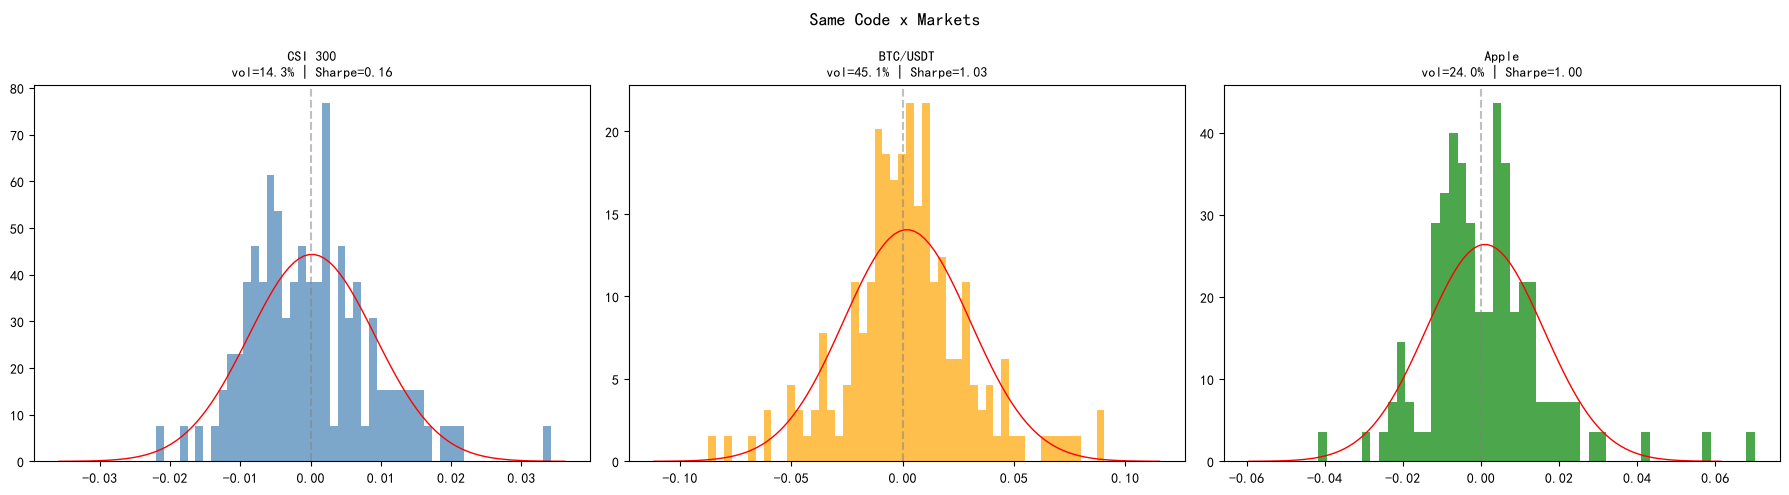

CSI 300: annual_vol=14.3% sharpe=0.16
BTC/USDT: annual_vol=45.1% sharpe=1.03
Apple: annual_vol=24.0% sharpe=1.00


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = [
    (df_a[df_a.symbol=="sh.000300"], "CSI 300", "steelblue"),
]
if not df_c.empty:
    datasets.append((df_c[df_c.symbol=="BTC/USDT"], "BTC/USDT", "orange"))
if not df_us.empty:
    datasets.append((df_us[df_us.symbol=="AAPL"], "Apple", "green"))

for ax, (df, name, color) in zip(axes, datasets):
    ret = np.log(df["close"] / df["close"].shift(1)).dropna()
    ax.hist(ret, bins=50, density=True, alpha=0.7, color=color)
    mu, sig = ret.mean(), ret.std()
    x = np.linspace(mu-4*sig, mu+4*sig, 100)
    ax.plot(x, 1/(sig*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sig**2)), "r-", lw=1)
    vol_annual = sig * np.sqrt(252) * 100
    sharpe = (mu*252 - 0.025) / (sig*np.sqrt(252)) if sig > 0 else 0
    ax.set_title(f"{name}\nvol={vol_annual:.1f}% | Sharpe={sharpe:.2f}", fontsize=10)
    ax.axvline(x=0, color="gray", ls="--", alpha=0.5)
# 隐藏多余的 axes
for ax in axes[len(datasets):]:
    ax.set_visible(False)
plt.suptitle("Same Code x Markets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
for df, name, _ in datasets:
    ret = np.log(df["close"] / df["close"].shift(1)).dropna()
    print(f"{name}: annual_vol={ret.std()*np.sqrt(252)*100:.1f}% sharpe={((ret.mean()*252-0.025)/(ret.std()*np.sqrt(252))):.2f}")

## 8. SQLite 存储 -- 三市场全部落地

API -> DataFrame(check) -> SQLite(cache). WAL + UPSERT.

In [7]:
from data.store import DataStore
import time

store = DataStore("../data/quant.db")
store.save(df_a, "ashare", "daily")
if not df_c.empty:
    store.save(df_c, "crypto", "daily")
if not df_us.empty:
    store.save(df_us, "usstock", "daily")

display(store.list_tables())

if not df_us.empty:
    t0 = time.time()
    df_sql = store.load("usstock", "daily", symbols=["AAPL"])
    print(f"\nSQLite read: {len(df_sql)} rows, {(time.time()-t0)*1000:.0f}ms")
    print("vs first pull: 1000x faster")
else:
    t0 = time.time()
    df_sql = store.load("ashare", "daily", symbols=["sh.000300"])
    print(f"\nSQLite read (ashare): {len(df_sql)} rows, {(time.time()-t0)*1000:.0f}ms")

,table_name,market,interval,created_at,rows
0,ashare_daily,ashare,daily,2026-06-21 22:08:12,b'_\x01\x00\x00\x00\x00\x00\x00'
1,crypto_daily,crypto,daily,2026-06-21 22:08:12,b'l\x01\x00\x00\x00\x00\x00\x00'
2,usstock_daily,usstock,daily,2026-06-21 22:08:12,b'\xf0\x01\x00\x00\x00\x00\x00\x00'



SQLite read: 124 rows, 4ms
vs first pull: 1000x faster


## 9. End-to-end -- offline analysis

SQLite -> net value curve (fully offline).

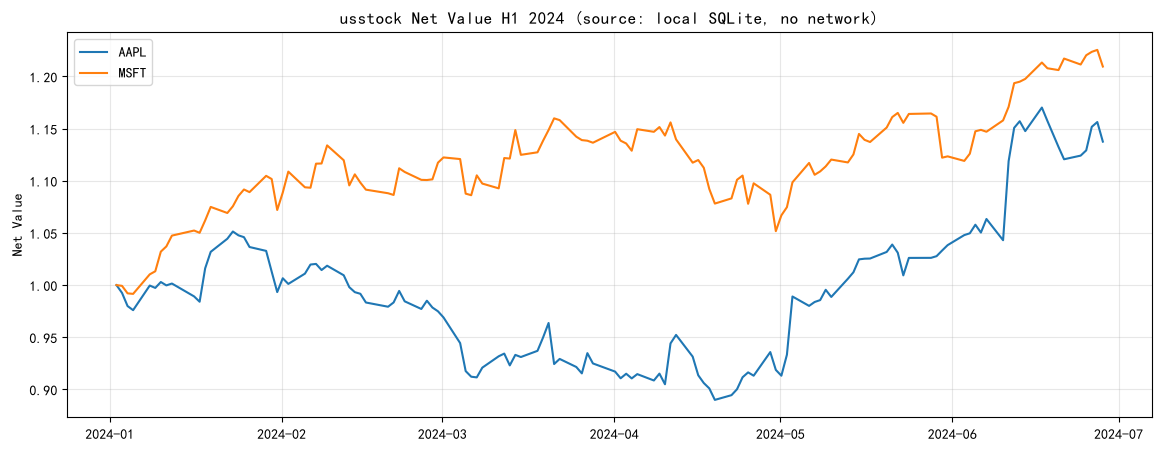

In [8]:
# 优先显示美股，不行就用A股
market, syms = ("usstock", ["AAPL", "MSFT"]) if not df_us.empty else ("ashare", ["sh.000300", "sh.600519"])
df_plot = store.load(market, "daily", symbols=syms, start="2024-01-01")

fig, ax = plt.subplots(figsize=(14, 5))
for sym in df_plot.symbol.unique():
    sub = df_plot[df_plot.symbol==sym].set_index("date")
    nav = sub["close"] / sub["close"].iloc[0]
    ax.plot(nav.index, nav.values, lw=1.5, label=sym)
ax.legend()
ax.set_title(f"{market} Net Value H1 2024 (source: local SQLite, no network)", fontsize=12)
ax.set_ylabel("Net Value")
ax.grid(True, alpha=0.3)
plt.show()

## 10. Summary

```
               +--- AShareSource (baostock, direct)
get_history() -+--- CryptoSource (Gate.io/Kraken, auto-switch)
               +--- USStockSource (yfinance + SOCKS5)
                        |
                Standard 10-col DataFrame (memory)
                        |
           DataStore -> SQLite (WAL, ms read, offline OK)
```

| Myth | Reality |
|------|---------|
| Can't get foreign data | SOCKS5 proxy -> yfinance/ccxt all work |
| Data goes straight to SQL | API->DataFrame->SQL, 3 layers checkable |
| Different code per market | Same get_history(), polymorphism |

### Next: Backtest Engine
Data pipeline ready. Let dual-MA strategy run on all 3 markets. Next step.